In [ ]:
%pip install -r requirements.txt

# Original Code (with tiny modification)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error as mae
import seaborn as sns
from datetime import datetime
import holidays
from ipywidgets import interact
import ipywidgets as widgets

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('StoreDemand.csv')
display(df.head())
display(df.tail())

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


,date,store,item,sales
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62
912999,2017-12-31,10,50,82


In [3]:
df.shape

(913000, 4)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB


In [5]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [6]:
parts = df["date"].str.split("-", n = 3, expand = True)
df["year"]= parts[0].astype('int')
df["month"]= parts[1].astype('int')
df["day"]= parts[2].astype('int')
display(df.head())

,date,store,item,sales,year,month,day
0,2013-01-01,1,1,13,2013,1,1
1,2013-01-02,1,1,11,2013,1,2
2,2013-01-03,1,1,14,2013,1,3
3,2013-01-04,1,1,13,2013,1,4
4,2013-01-05,1,1,10,2013,1,5


In [7]:
def weekend_or_weekday(year, month, day):
    d = datetime(year, month, day)
    return 1 if d.weekday() > 4 else 0

df['weekend'] = df.apply(lambda x: weekend_or_weekday(x['year'], x['month'], x['day']), axis=1)
display(df.head())

,date,store,item,sales,year,month,day,weekend
0,2013-01-01,1,1,13,2013,1,1,0
1,2013-01-02,1,1,11,2013,1,2,0
2,2013-01-03,1,1,14,2013,1,3,0
3,2013-01-04,1,1,13,2013,1,4,0
4,2013-01-05,1,1,10,2013,1,5,1


In [8]:
india_holidays = holidays.country_holidays('IN')
df['holidays'] = df['date'].apply(lambda x: 1 if india_holidays.get(x) else 0)
display(df.head())

,date,store,item,sales,year,month,day,weekend,holidays
0,2013-01-01,1,1,13,2013,1,1,0,0
1,2013-01-02,1,1,11,2013,1,2,0,0
2,2013-01-03,1,1,14,2013,1,3,0,0
3,2013-01-04,1,1,13,2013,1,4,0,0
4,2013-01-05,1,1,10,2013,1,5,1,0


In [9]:
df['m1'] = np.sin(df['month'] * (2 * np.pi / 12))
df['m2'] = np.cos(df['month'] * (2 * np.pi / 12))
display(df.head())

,date,store,item,sales,year,month,day,weekend,holidays,m1,m2
0,2013-01-01,1,1,13,2013,1,1,0,0,0.5,0.866025
1,2013-01-02,1,1,11,2013,1,2,0,0,0.5,0.866025
2,2013-01-03,1,1,14,2013,1,3,0,0,0.5,0.866025
3,2013-01-04,1,1,13,2013,1,4,0,0,0.5,0.866025
4,2013-01-05,1,1,10,2013,1,5,1,0,0.5,0.866025


In [10]:
def which_day(year, month, day):
    return datetime(year, month, day).weekday()

df['weekday'] = df.apply(lambda x: which_day(x['year'], x['month'], x['day']), axis=1)
display(df.head())

,date,store,item,sales,year,month,day,weekend,holidays,m1,m2,weekday
0,2013-01-01,1,1,13,2013,1,1,0,0,0.5,0.866025,1
1,2013-01-02,1,1,11,2013,1,2,0,0,0.5,0.866025,2
2,2013-01-03,1,1,14,2013,1,3,0,0,0.5,0.866025,3
3,2013-01-04,1,1,13,2013,1,4,0,0,0.5,0.866025,4
4,2013-01-05,1,1,10,2013,1,5,1,0,0.5,0.866025,5


In [11]:
df.drop('date', axis=1, inplace=True)
display(df.head())

,store,item,sales,year,month,day,weekend,holidays,m1,m2,weekday
0,1,1,13,2013,1,1,0,0,0.5,0.866025,1
1,1,1,11,2013,1,2,0,0,0.5,0.866025,2
2,1,1,14,2013,1,3,0,0,0.5,0.866025,3
3,1,1,13,2013,1,4,0,0,0.5,0.866025,4
4,1,1,10,2013,1,5,1,0,0.5,0.866025,5


In [12]:
df['store'].nunique(), df['item'].nunique()

(10, 50)

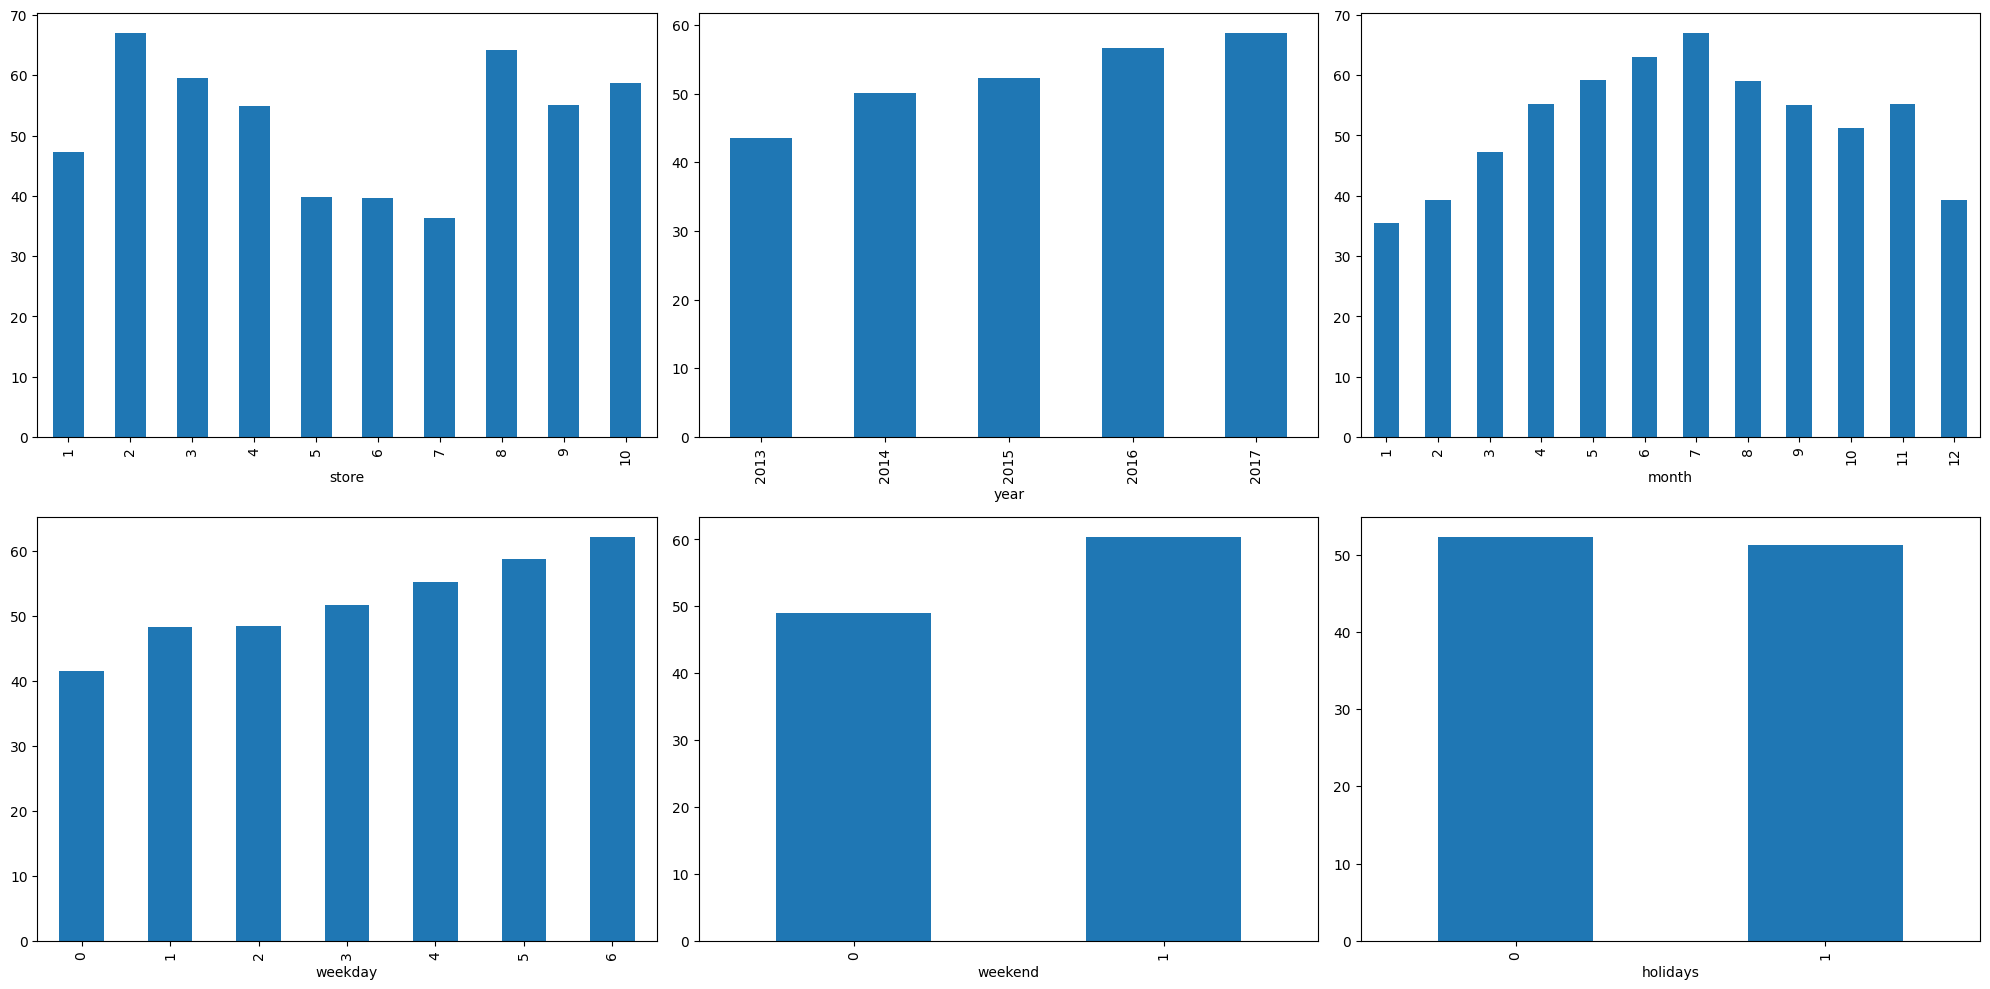

In [13]:
df['weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
features = ['store', 'year', 'month', 'weekday', 'weekend', 'holidays']

# Gunakan plt.figure, BUKAN plt.subplots
plt.figure(figsize=(20, 10))

for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    df.groupby(col).mean()['sales'].plot.bar()

plt.tight_layout() # Tetap dipertahankan agar teks X dan Y tidak tabrakan
plt.show()

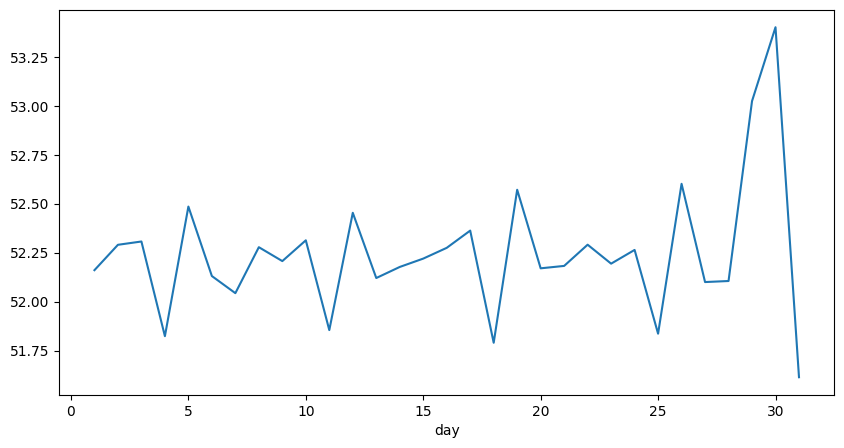

In [14]:
plt.figure(figsize=(10,5))
df.groupby('day').mean()['sales'].plot()
plt.show()

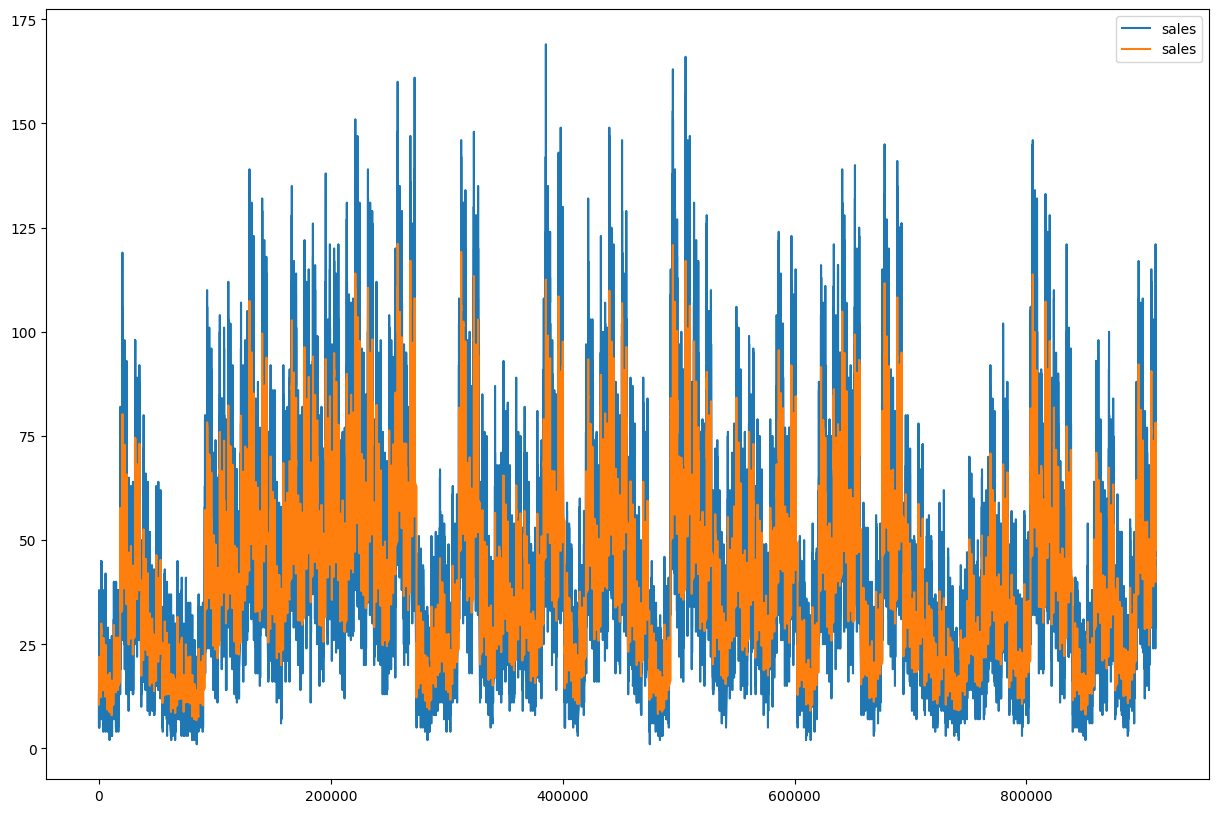

In [15]:
plt.figure(figsize=(15, 10))

# Calculating Simple Moving Average 
# for a window period of 30 days
window_size = 30
data = df[df['year']==2013]
windows = data['sales'].rolling(window_size)
sma = windows.mean()
sma = sma[window_size - 1:]

data['sales'].plot()
sma.plot()
plt.legend()
plt.show()

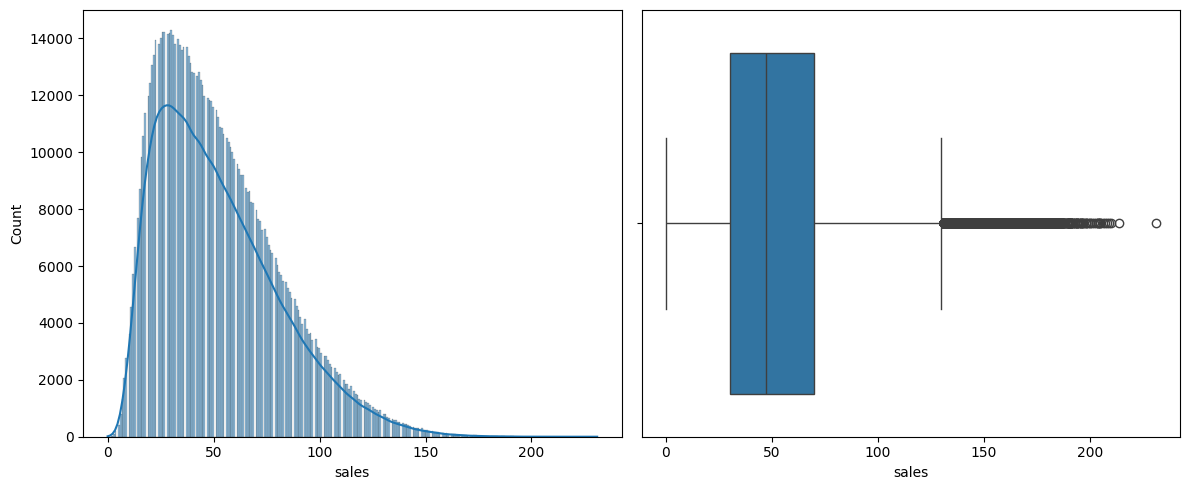

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Mengganti distplot dengan histplot dan mengaktifkan garis kurva KDE
sb.histplot(df['sales'], kde=True)

plt.subplot(1, 2, 2)
# Menambahkan x= agar boxplot merender secara horizontal mengikuti sumbu X
sb.boxplot(x=df['sales']) 

plt.tight_layout()
plt.show()

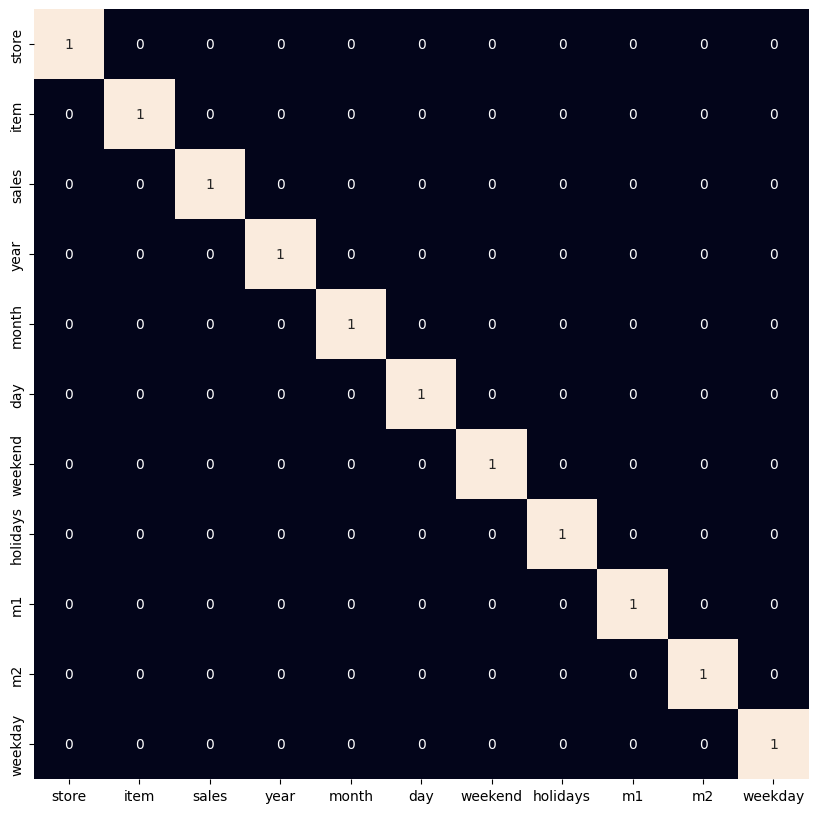

In [17]:
plt.figure(figsize=(10, 10))
sb.heatmap(df.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()

In [18]:
df_input = df[df['sales']<140]

In [19]:
features1 = df_input.drop(['sales', 'year'], axis=1)
target1 = df_input['sales'].values

X_train, X_val, Y_train, Y_val = train_test_split(features1, target1,
                                                  test_size = 0.05,
                                                  random_state=22)
X_train.shape, X_val.shape

((861170, 9), (45325, 9))

In [20]:
# Normalizing the features for stable and fast training.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [21]:
lr_model = LinearRegression()
ridge = Ridge()
lasso = Lasso()
xgb = XGBRegressor()

models = {
    'Linear Regression': lr_model,
    'Ridge (Untuned)': ridge,
    'Lasso (Untuned)': lasso,
    'XGBoost (Untuned)': xgb
}

best_trained_untuned_models = {}

df_plot = X_val.copy()
df_plot['Actual_Sales'] = Y_val

for name, model in models.items():
    model.fit(X_train, Y_train)

    print(f'{model} : ')

    if hasattr(model, 'best_params_'):
        print(f"  Parameter Terbaik: {model.best_params_}")
        best_model = model.best_estimator_
    else:
        best_model = model
        
    best_trained_untuned_models[name] = best_model
    
    train_preds = model.predict(X_train)
    print('Training Error : ', mae(Y_train, train_preds))

    val_preds = model.predict(X_val)
    print('Validation Error : ', mae(Y_val, val_preds))
    print()
    
    df_plot[f'Pred_{name}'] = val_preds

LinearRegression() : 
Training Error :  20.903011639935794
Validation Error :  20.971878842602617

Ridge() : 
Training Error :  20.903011813622665
Validation Error :  20.971879087634257

Lasso() : 
Training Error :  20.98182946540371
Validation Error :  21.052182092224857

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_p

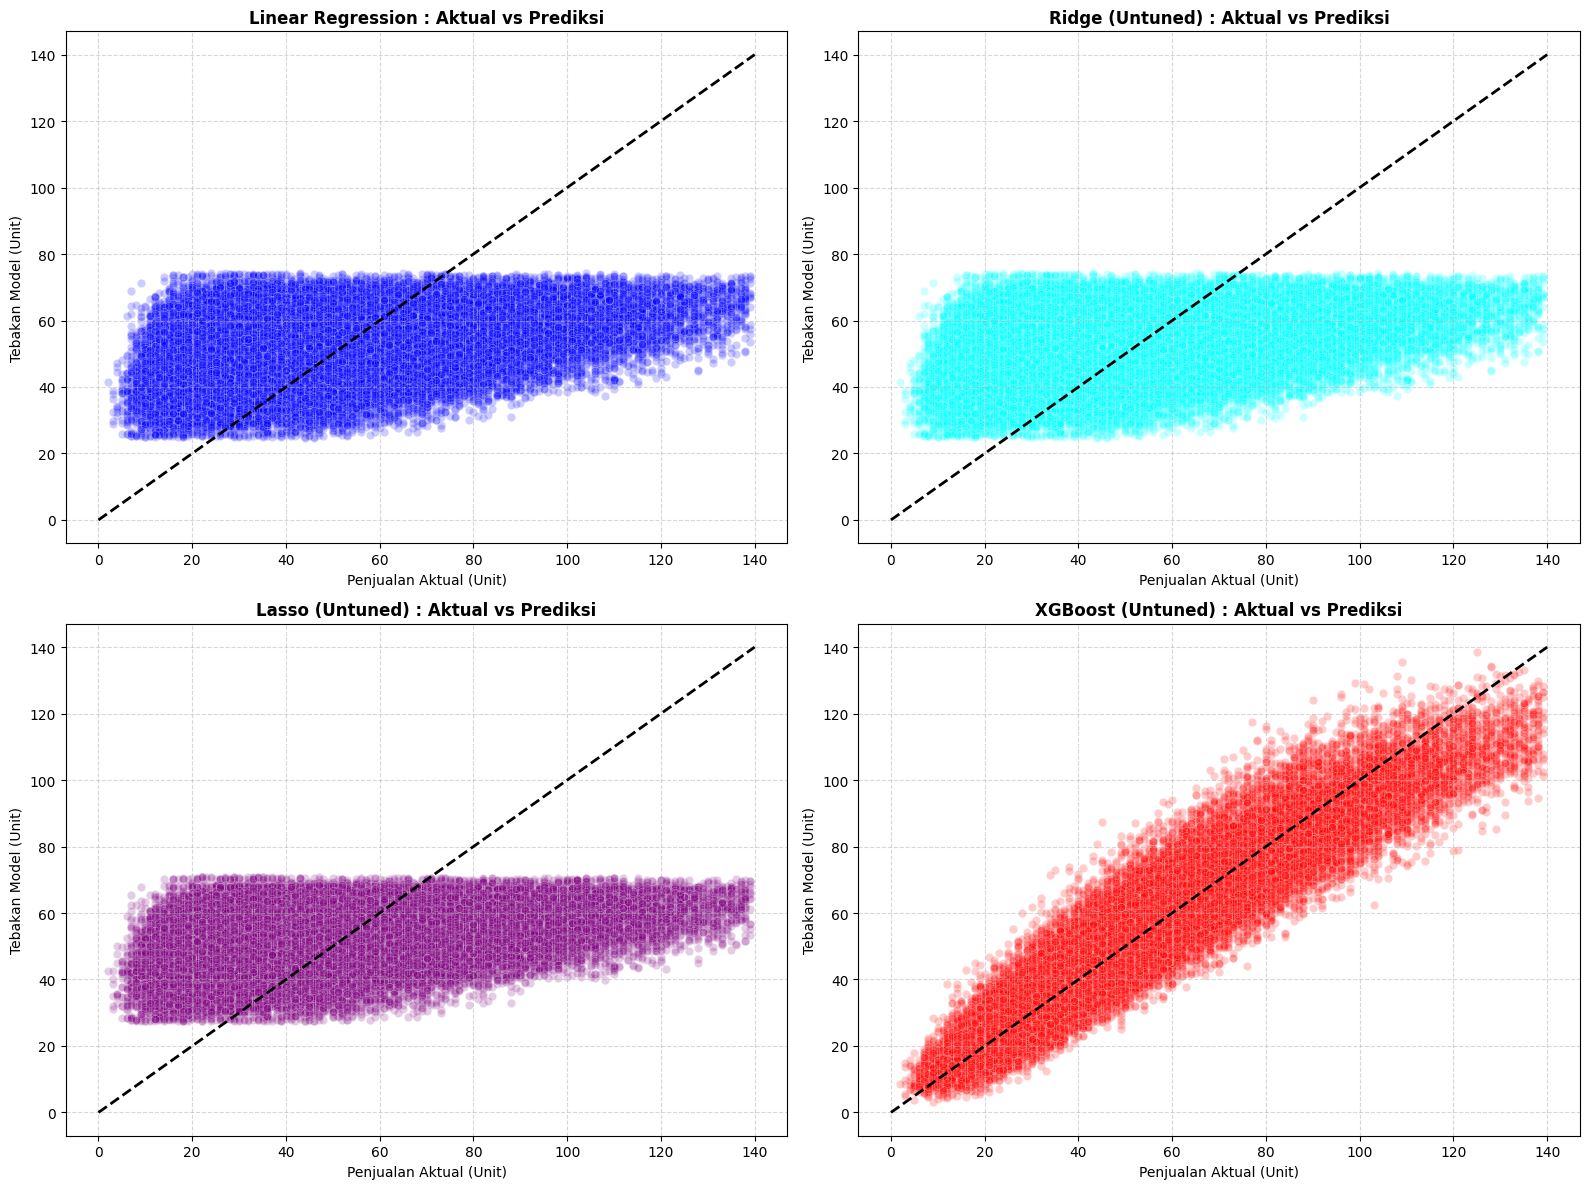

In [22]:
# Membuat kanvas grid 2 baris x 2 kolom
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # Meratakan matriks agar mudah di-loop

# Definisi nama model, nama kolom di df_plot, dan warnanya
models_to_plot = [
    ('Linear Regression', 'Pred_Linear Regression', 'blue'),
    ('Ridge (Untuned)', 'Pred_Ridge (Untuned)', 'cyan'),
    ('Lasso (Untuned)', 'Pred_Lasso (Untuned)', 'purple'),
    ('XGBoost (Untuned)', 'Pred_XGBoost (Untuned)', 'red')
]

for i, (nama_model, nama_kolom, warna) in enumerate(models_to_plot):
    # Memastikan kolom prediksi tersebut benar-benar ada
    if nama_kolom in df_plot.columns:
        sns.scatterplot(x=df_plot['Actual_Sales'], y=df_plot[nama_kolom], 
                        alpha=0.2, color=warna, ax=axes[i])
        
        # Menggambar garis diagonal ideal (Kenyataan = Tebakan)
        axes[i].plot([0, 140], [0, 140], color='black', linestyle='--', linewidth=2) 
        
        axes[i].set_title(f'{nama_model} : Aktual vs Prediksi', fontweight='bold')
        axes[i].set_xlabel('Penjualan Aktual (Unit)')
        axes[i].set_ylabel('Tebakan Model (Unit)')
        axes[i].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Modification

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error as mae
from ipywidgets import interact
import ipywidgets as widgets

# ==============================================================================
# 1. PERSIAPAN DATA & SKENARIO 3 (STRICT TIME-BASED SPLIT)
# ==============================================================================

# WAJIB: Pengurutan Hierarkis Waktu sebelum splitting
df_input2 = df_input.sort_values(by=['year', 'month', 'day', 'store', 'item']).reset_index(drop=True)

display(df_input2.head())

,store,item,sales,year,month,day,weekend,holidays,m1,m2,weekday
0,1,1,13,2013,1,1,0,0,0.5,0.866025,1
1,1,2,33,2013,1,1,0,0,0.5,0.866025,1
2,1,3,15,2013,1,1,0,0,0.5,0.866025,1
3,1,4,10,2013,1,1,0,0,0.5,0.866025,1
4,1,5,11,2013,1,1,0,0,0.5,0.866025,1


In [25]:
features = df_input2.drop(['month', 'sales'], axis=1)
target = df_input2['sales'].values

# Split Latih (2013-2016) dan Ujian (2017)
train_mask = features['year'] < 2017
val_mask = features['year'] == 2017

X_train_mod, X_val_mod = features[train_mask], features[val_mask]
Y_train_mod, Y_val_mod = target[train_mask], target[val_mask]

# Scaling Fitur
scaler = StandardScaler()
X_train__mod_scaled = scaler.fit_transform(X_train_mod)
X_val__mod_scaled = scaler.transform(X_val_mod)

print(f"Data Latih (2013-2016) : {len(X_train_mod)} baris")
print(f"Data Uji (2017)        : {len(X_val_mod)} baris\n")

# ==============================================================================
# 2. DEFINISI MODEL & HYPERPARAMETER TUNING (DENGAN RF & TIME SERIES SPLIT)
# ==============================================================================
print("2. Memulai Proses Training & Tuning (Tunggu hingga selesai)...\n")

tscv = TimeSeriesSplit(n_splits=3)

# A. Linear Regression (Tanpa Tuning)
lr_model_mod = LinearRegression()

# B. Ridge Regression
ridge_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_search = GridSearchCV(Ridge(), param_grid=ridge_params, scoring='neg_mean_absolute_error', cv=tscv)

# C. Lasso Regression
lasso_params = {'alpha': [0.01, 0.1, 1.0, 10.0]}
lasso_search = GridSearchCV(Lasso(max_iter=2000), param_grid=lasso_params, scoring='neg_mean_absolute_error', cv=tscv)

# D. Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5]
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=22, n_jobs=-1),
    param_distributions=rf_params,
    n_iter=4, 
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=22
)

# E. XGBoost
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', random_state=22, n_jobs=-1),
    param_distributions=xgb_params,
    n_iter=10, 
    scoring='neg_mean_absolute_error',
    cv=tscv,
    random_state=22
)

# Kamus Kelompok Model
models = {
    'Linear Regression': lr_model_mod,
    'Ridge (Tuned)': ridge_search,
    'Lasso (Tuned)': lasso_search,
    'Random Forest (Tuned)': rf_search,
    'XGBoost (Tuned)': xgb_search
}

# ==============================================================================
# 3. EKSEKUSI & EVALUASI MAE MASA DEPAN (TAHUN 2017)
# ==============================================================================
df_plot = X_val.copy()
df_plot['Actual_Sales'] = Y_val

print("=== HASIL EVALUASI MAE TAHUN 2017 ===")
for name, model in models.items():
    print(f"Sedang memproses {name}...")
    model.fit(X_train_scaled, Y_train)
    
    if hasattr(model, 'best_params_'):
        print(f"   Parameter Terbaik: {model.best_params_}")
        
    preds = model.predict(X_val_scaled)
    error = mae(Y_val, preds)
    print(f"   MAE di Tahun 2017: {error:.4f} unit\n")
    
    # Menyimpan prediksi untuk visualisasi dashboard
    df_plot[f'Pred_{name}'] = preds

print("Semua model berhasil dilatih!\n")

# ==============================================================================
# 4. DASBOR VISUALISASI KOMPARASI 5 MODEL
# ==============================================================================
def visualisasi_5_model(toko_id, item_id):
    masker = (df_plot['store'] == toko_id) & (df_plot['item'] == item_id)
    df_mikro = df_plot[masker].copy()
    
    if len(df_mikro) == 0:
        print("Data tidak ditemukan.")
        return
        
    df_mikro['hari_ke'] = np.arange(len(df_mikro))
    
    plt.figure(figsize=(16, 7))
    
    # Tren Aktual (Garis Hitam Tebal)
    aktual_smooth = df_mikro['Actual_Sales'].rolling(7, min_periods=1).mean()
    plt.plot(df_mikro['hari_ke'], aktual_smooth, label='Kenyataan (Aktual 2017)', color='black', linewidth=3, zorder=5)
    
    # Pemetaan Gaya Visualisasi Tiap Model
    gaya_model = {
        'Pred_Linear Regression': ('blue', ':', 0.7),
        'Pred_Ridge (Tuned)': ('cyan', '-.', 0.7),
        'Pred_Lasso (Tuned)': ('purple', '-.', 0.7),
        'Pred_Random Forest (Tuned)': ('green', '--', 1.5),  # Random Forest garis hijau putus-putus
        'Pred_XGBoost (Tuned)': ('red', '--', 2.0)            # XGBoost garis merah putus-putus tebal
    }
    
    for kolom, (warna, garis, tebal) in gaya_model.items():
        if kolom in df_mikro.columns:
            pred_smooth = df_mikro[kolom].rolling(7, min_periods=1).mean()
            nama_label = kolom.replace('Pred_', '')
            plt.plot(df_mikro['hari_ke'], pred_smooth, label=nama_label, 
                     color=warna, linestyle=garis, linewidth=tebal)
    
    plt.title(f'Komparasi Hasil Prediksi Tahun 2017: Toko {toko_id} | Barang {item_id}', fontsize=14, fontweight='bold')
    plt.xlabel('Indeks Hari Sepanjang Tahun 2017 (Januari - Desember)', fontsize=12)
    plt.ylabel('Rata-rata Penjualan (7-Day MA)', fontsize=12)
    plt.ylim(bottom=0)
    
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Memanggil UI Slider Interaktif
interact(
    visualisasi_5_model, 
    toko_id=widgets.IntSlider(min=1, max=10, step=1, value=1, description='Pilih Toko:'),
    item_id=widgets.IntSlider(min=1, max=50, step=1, value=1, description='Pilih Barang:')
)

Data Latih (2013-2016) : 726880 baris
Data Uji (2017)        : 179615 baris

2. Memulai Proses Training & Tuning (Tunggu hingga selesai)...

=== HASIL EVALUASI MAE TAHUN 2017 ===
Sedang memproses Linear Regression...
   MAE di Tahun 2017: 20.9719 unit

Sedang memproses Ridge (Tuned)...
   Parameter Terbaik: {'alpha': 0.1}
   MAE di Tahun 2017: 20.9719 unit

Sedang memproses Lasso (Tuned)...
   Parameter Terbaik: {'alpha': 0.01}
   MAE di Tahun 2017: 20.9725 unit

Sedang memproses Random Forest (Tuned)...
   Parameter Terbaik: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}
   MAE di Tahun 2017: 13.0953 unit

Sedang memproses XGBoost (Tuned)...
   Parameter Terbaik: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1}
   MAE di Tahun 2017: 6.4728 unit

Semua model berhasil dilatih!



interactive(children=(IntSlider(value=1, description='Pilih Toko:', max=10, min=1), IntSlider(value=1, descrip…

<function __main__.visualisasi_5_model(toko_id, item_id)>